<a href="https://colab.research.google.com/github/songnee/test/blob/main/7_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 회귀 모델 비교 (Boston Housing Dataset)

Ridge(L2), Lasso(L1), SVR, DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor 6가지 모델을 **동일한 데이터, 동일한 전처리, 동일한 평가 기준**으로 비교합니다.

**공통 파이프라인:**
1. 데이터 로드 및 확인
2. 학습/테스트 분할 (test_size=0.3, random_state=42)
3. StandardScaler 적용
4. 모델 학습
5. Train/Test Score 출력
6. 평가지표 출력 (MAE, MAPE, MSE, RMSE, R2)
7. 실제값 vs 예측값 시각화

---
## 0. 공통 셋업 (Import, 데이터 로드, 전처리)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 평가 함수 정의
def evaluate_reg_model(y_test, y_pred):
    print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred):.4f}")
    print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
    print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.4f}")
    print(f"R2   : {r2_score(y_test, y_pred):.4f}")

# 시각화 함수 정의
def plot_prediction(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_test, label="실제값 기준선", alpha=0.5)
    sns.scatterplot(x=y_test, y=y_pred, label=f"{model_name} 예측값")
    plt.xlabel("실제값")
    plt.ylabel("예측값")
    plt.title(f"{model_name} - 실제값 vs 예측값")
    plt.legend()
    plt.show()

In [ ]:
# 데이터 로드
df = pd.read_csv("./dataset/boston.csv")

X = df[df.columns[:-1]]
y = df[df.columns[-1]]

print(f"데이터 shape: {df.shape}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
df.head()

데이터 shape: (506, 14)
X shape: (506, 13), y shape: (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# StandardScaler 적용
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Train: (354, 13), Test: (152, 13)


---
## 1. Ridge Regression (L2 규제)

### 알고리즘 원리
- 선형 회귀에 **L2 정규화(패널티)**를 추가한 모델
- 손실 함수: $\text{MSE} + \alpha \sum w_i^2$ (가중치의 **제곱합**을 패널티로 부여)
- 가중치를 **0에 가깝게** 줄이지만 정확히 0으로 만들지는 않음
- 다중공선성(multicollinearity) 문제를 완화하는 데 효과적

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `alpha` | 규제 강도 (클수록 가중치를 더 강하게 축소) |

### 특징
- **스케일링 필수** (규제가 가중치 크기에 의존)
- 모든 feature를 유지하면서 과적합을 방지
- feature 수가 많고 대부분이 유의미할 때 적합

In [ ]:
# 모델 생성 및 학습 (스케일링된 데이터 사용)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Score 확인
print(f"Train Score: {ridge.score(X_train_scaled, y_train):.4f}")
print(f"Test  Score: {ridge.score(X_test_scaled, y_test):.4f}")
print()

# 예측 및 평가
y_pred_ridge = ridge.predict(X_test_scaled)
evaluate_reg_model(y_test, y_pred_ridge)

Train Score: 0.7435
Test  Score: 0.7108

MAE  : 3.1610
MAPE : 0.1651
MSE  : 21.5487
RMSE : 4.6421
R2   : 0.7108


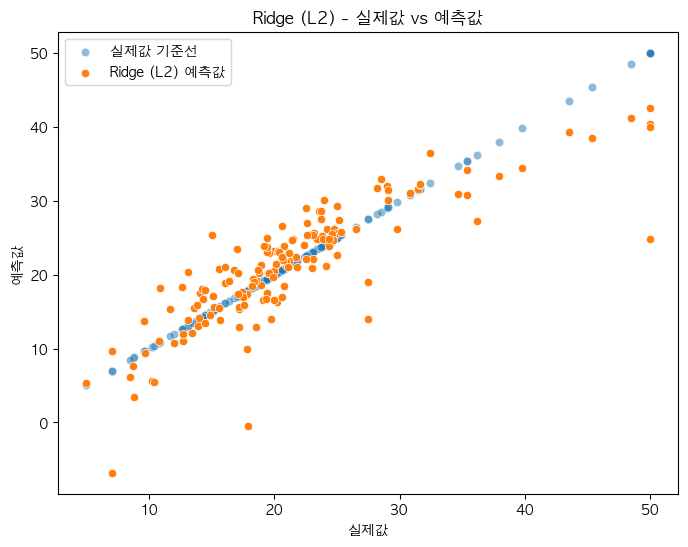

Ridge 회귀 계수:
      CRIM: -1.0959
        ZN: +0.7882
     INDUS: +0.3141
      CHAS: +0.8194
       NOX: -1.7616
        RM: +2.9199
       AGE: -0.3016
       DIS: -2.9023
       RAD: +2.0128
       TAX: -1.3761
   PTRATIO: -2.0411
         B: +1.0210
     LSTAT: -3.8712


In [ ]:
# 시각화
plot_prediction(y_test, y_pred_ridge, "Ridge (L2)")

# Ridge 회귀 계수 확인
print("Ridge 회귀 계수:")
for name, coef in zip(X.columns, ridge.coef_):
    print(f"  {name:>8s}: {coef:+.4f}")

---
## 2. Lasso Regression (L1 규제)

### 알고리즘 원리
- 선형 회귀에 **L1 정규화(패널티)**를 추가한 모델
- 손실 함수: $\text{MSE} + \alpha \sum |w_i|$ (가중치의 **절대값 합**을 패널티로 부여)
- 가중치를 **정확히 0으로** 만들 수 있음 → **Feature Selection 효과**
- 불필요한 feature를 자동으로 제거

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `alpha` | 규제 강도 (클수록 더 많은 feature의 가중치가 0이 됨) |

### 특징
- **스케일링 필수** (규제가 가중치 크기에 의존)
- 불필요한 feature를 자동 제거하여 **모델 해석이 쉬움**
- feature 수가 많고 일부만 유의미할 때 적합

### Ridge vs Lasso 비교
| 구분 | Ridge (L2) | Lasso (L1) |
|------|-----------|-----------|
| 패널티 | $\sum w_i^2$ | $\sum \|w_i\|$ |
| 가중치 축소 | 0에 가깝게 | 정확히 0으로 |
| Feature Selection | 불가 | **가능** |
| 다중공선성 처리 | 우수 | 하나만 선택, 나머지 제거 |

In [ ]:
# 모델 생성 및 학습 (스케일링된 데이터 사용)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Score 확인
print(f"Train Score: {lasso.score(X_train_scaled, y_train):.4f}")
print(f"Test  Score: {lasso.score(X_test_scaled, y_test):.4f}")
print()

# 예측 및 평가
y_pred_lasso = lasso.predict(X_test_scaled)
evaluate_reg_model(y_test, y_pred_lasso)

Train Score: 0.7377
Test  Score: 0.6942

MAE  : 3.2088
MAPE : 0.1668
MSE  : 22.7885
RMSE : 4.7737
R2   : 0.6942


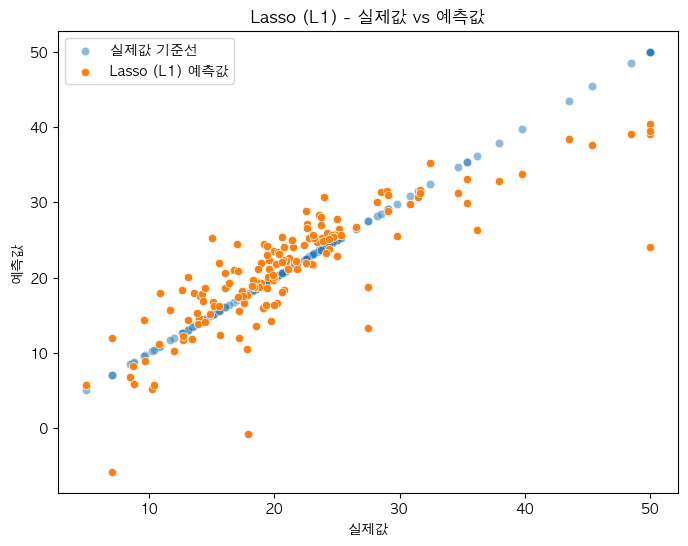

Lasso 회귀 계수:
      CRIM: -0.8037
        ZN: +0.3844
     INDUS: -0.0000 ← 제거됨
      CHAS: +0.8245
       NOX: -1.2875
        RM: +3.0021
       AGE: -0.1253
       DIS: -2.1497
       RAD: +0.5190
       TAX: -0.0595
   PTRATIO: -1.8948
         B: +0.9141
     LSTAT: -3.9154

사용된 feature 수: 12 / 13


In [ ]:
# 시각화
plot_prediction(y_test, y_pred_lasso, "Lasso (L1)")

# Lasso 회귀 계수 확인 (0인 feature = 제거된 feature)
print("Lasso 회귀 계수:")
for name, coef in zip(X.columns, lasso.coef_):
    marker = " ← 제거됨" if coef == 0 else ""
    print(f"  {name:>8s}: {coef:+.4f}{marker}")

print(f"\n사용된 feature 수: {np.sum(lasso.coef_ != 0)} / {len(lasso.coef_)}")

---
## 3. SVR (Support Vector Regression)
![](https://velog.velcdn.com/images/newnew_daddy/post/67eea226-2d8f-4e2b-bb26-f61c573b513e/image.png)
### 알고리즘 원리
- 분류에서 사용하는 SVM(Support Vector Machine)을 회귀 문제에 적용한 모델
- SVM은 클래스 간 분리를 최대화하는 결정 경계를 생성하는 알고리즘
- SVR은 **마진(epsilon-tube) 안에 최대한 많은 데이터가 들어오도록** 학습
- 마진 밖에 있는 오차(Error)를 최소화하는 것이 목적

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `kernel` | 커널 함수 (`rbf`, `linear`, `poly` 등) |
| `C` | 정규화 강도 (클수록 오차에 민감) |
| `epsilon` | 마진 폭 (이 범위 안의 오차는 무시) |
| `gamma` | RBF 커널의 영향 범위 (`scale`, `auto`) |

### 특징
- **스케일링 필수** (거리 기반 알고리즘)
- 비선형 관계도 커널 트릭으로 학습 가능
- 데이터가 많으면 학습이 느려질 수 있음

In [ ]:
# 모델 생성 및 학습
svr = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='auto')
svr.fit(X_train_scaled, y_train)

# Score 확인
print(f"Train Score: {svr.score(X_train_scaled, y_train):.4f}")
print(f"Test  Score: {svr.score(X_test_scaled, y_test):.4f}")
print()

# 예측 및 평가
y_pred_svr = svr.predict(X_test_scaled)
evaluate_reg_model(y_test, y_pred_svr)

Train Score: 0.9730
Test  Score: 0.8380

MAE  : 2.1605
MAPE : 0.1195
MSE  : 12.0748
RMSE : 3.4749
R2   : 0.8380


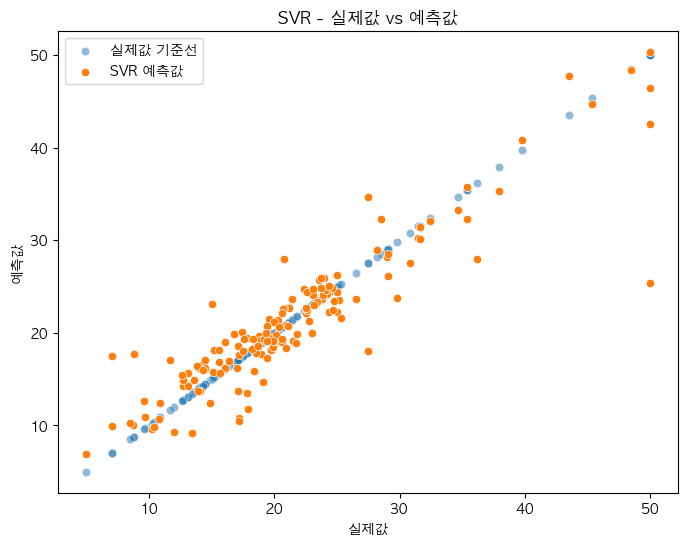

In [ ]:
# 시각화
plot_prediction(y_test, y_pred_svr, "SVR")

---
## 4. DecisionTreeRegressor (결정트리 회귀)
![](https://velog.velcdn.com/images/newnew_daddy/post/d22627eb-7eb0-4901-a46f-efac8d8fca86/image.png)
### 알고리즘 원리
- 결정 트리 알고리즘을 사용하여 연속형 타겟 값을 예측하는 회귀 모델
- 분기마다 **MSE가 감소하는 방향**으로 분할하여 값을 예측
- 리프 노드에 도달한 학습 데이터의 **평균값**을 예측값으로 사용

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `max_depth` | 트리 최대 깊이 (과적합 방지 핵심) |
| `min_samples_split` | 노드 분할에 필요한 최소 샘플 수 |
| `min_samples_leaf` | 리프 노드의 최소 샘플 수 |
| `max_features` | 분할 시 고려할 최대 feature 수 |

### 특징
- **스케일링 불필요** (트리 기반 알고리즘은 분할 기준만 사용)
- 해석이 쉬움 (트리 시각화 가능)
- 깊이 제한 없으면 과적합되기 매우 쉬움

In [ ]:
# 모델 생성 및 학습 (트리 기반은 스케일링 안 된 원본 데이터 사용)
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Score 확인
print(f"Train Score: {dt.score(X_train, y_train):.4f}")
print(f"Test  Score: {dt.score(X_test, y_test):.4f}")
print()

# 예측 및 평가
y_pred_dt = dt.predict(X_test)
evaluate_reg_model(y_test, y_pred_dt)

Train Score: 0.9277
Test  Score: 0.8507

MAE  : 2.4755
MAPE : 0.1347
MSE  : 11.1221
RMSE : 3.3350
R2   : 0.8507


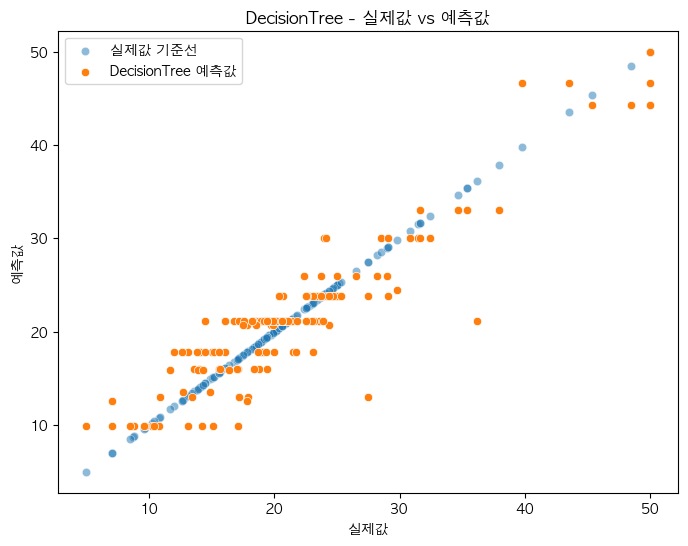

In [ ]:
# 시각화
plot_prediction(y_test, y_pred_dt, "DecisionTree")

---
## 5. RandomForestRegressor (랜덤 포레스트 회귀)

### 알고리즘 원리
- 여러 개의 결정 트리를 만들어 **배깅(Bagging)** 방식으로 앙상블하는 모델
- 각 트리는 **부트스트랩 샘플**(중복 허용 랜덤 샘플링)로 학습
- 분할 시 전체 feature가 아닌 **랜덤하게 선택된 일부 feature**만 사용
- 최종 예측값은 각 트리 예측값의 **평균**

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `n_estimators` | 트리 개수 (많을수록 안정적, 하지만 학습 시간 증가) |
| `max_depth` | 개별 트리 최대 깊이 |
| `min_samples_split` | 노드 분할에 필요한 최소 샘플 수 |
| `max_features` | 분할 시 고려할 feature 수 (`sqrt`, `log2` 등) |

### 특징
- 단일 결정 트리 대비 **과적합에 강함**
- 스케일링 불필요
- feature 중요도(`feature_importances_`)를 제공하여 해석 가능

In [ ]:
# 모델 생성 및 학습
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Score 확인
print(f"Train Score: {rf.score(X_train, y_train):.4f}")
print(f"Test  Score: {rf.score(X_test, y_test):.4f}")
print()

# 예측 및 평가
y_pred_rf = rf.predict(X_test)
evaluate_reg_model(y_test, y_pred_rf)

Train Score: 0.9735
Test  Score: 0.8669

MAE  : 2.0997
MAPE : 0.1098
MSE  : 9.9196
RMSE : 3.1495
R2   : 0.8669


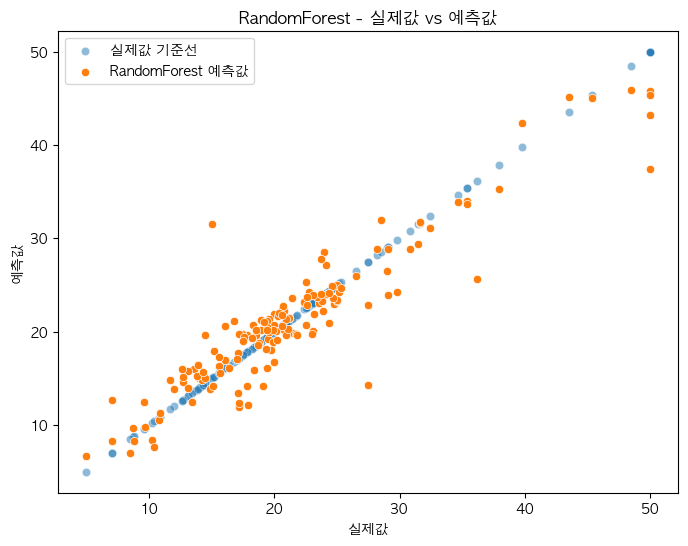

In [ ]:
# 시각화
plot_prediction(y_test, y_pred_rf, "RandomForest")

---
## 6. GradientBoostingRegressor (그래디언트 부스팅 회귀)

### 알고리즘 원리
- 여러 개의 약한 학습기(결정 트리)를 **순차적으로** 학습하는 **부스팅(Boosting)** 앙상블 모델
- 이전 모델의 **잔차(residual, 예측 오차)**를 다음 모델이 학습하여 보완
- 경사하강법을 사용하여 손실 함수를 최소화하는 방향으로 학습

### 주요 하이퍼파라미터
| 파라미터 | 설명 |
|---------|------|
| `n_estimators` | 부스팅 단계 수 (트리 개수) |
| `learning_rate` | 학습률 (각 트리의 기여도, 작을수록 안정적) |
| `max_depth` | 개별 트리 최대 깊이 (보통 3~5로 얕게 설정) |
| `subsample` | 각 트리 학습에 사용할 데이터 비율 |

### 특징
- 일반적으로 **가장 높은 예측 성능**을 보임
- 스케일링 불필요
- 순차 학습이라 **병렬처리 불가** (RandomForest보다 학습 느림)
- `learning_rate`와 `n_estimators`의 트레이드오프가 중요

In [ ]:
# 모델 생성 및 학습
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# Score 확인
print(f"Train Score: {gb.score(X_train, y_train):.4f}")
print(f"Test  Score: {gb.score(X_test, y_test):.4f}")
print()

# 예측 및 평가
y_pred_gb = gb.predict(X_test)
evaluate_reg_model(y_test, y_pred_gb)

Train Score: 0.9929
Test  Score: 0.8951

MAE  : 2.0038
MAPE : 0.1021
MSE  : 7.8189
RMSE : 2.7962
R2   : 0.8951


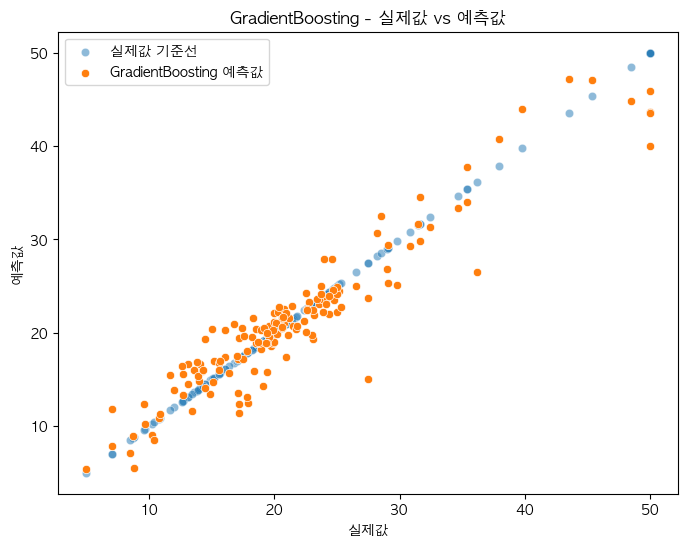

In [ ]:
# 시각화
plot_prediction(y_test, y_pred_gb, "GradientBoosting")

---
## 7. 모델 비교 요약

In [ ]:
# 모든 모델 성능을 한눈에 비교
results = {
    "Ridge (L2)": y_pred_ridge,
    "Lasso (L1)": y_pred_lasso,
    "SVR": y_pred_svr,
    "DecisionTree": y_pred_dt,
    "RandomForest": y_pred_rf,
    "GradientBoosting": y_pred_gb,
}

summary = []
for name, y_pred in results.items():
    summary.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    })

df_summary = pd.DataFrame(summary).set_index("Model")
df_summary.round(4)

,MAE,MAPE,MSE,RMSE,R2
Model,,,,,
Ridge (L2),3.1610,0.1651,21.5487,4.6421,0.7108
Lasso (L1),3.2088,0.1668,22.7885,4.7737,0.6942
SVR,2.1605,0.1195,12.0748,3.4749,0.8380
DecisionTree,2.4755,0.1347,11.1221,3.3350,0.8507
RandomForest,2.0997,0.1098,9.9196,3.1495,0.8669
GradientBoosting,2.0038,0.1021,7.8189,2.7962,0.8951


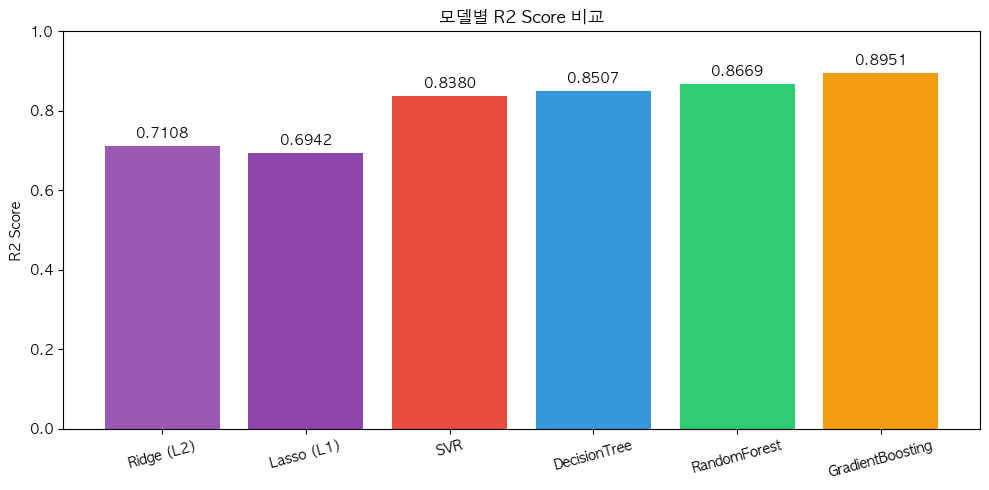

In [ ]:
# R2 Score 비교 시각화
plt.figure(figsize=(10, 5))
colors = ['#9b59b6', '#8e44ad', '#e74c3c', '#3498db', '#2ecc71', '#f39c12']
plt.bar(df_summary.index, df_summary["R2"], color=colors)
plt.ylabel("R2 Score")
plt.title("모델별 R2 Score 비교")
plt.ylim(0, 1)
plt.xticks(rotation=15)
for i, v in enumerate(df_summary["R2"]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()